# Finetuning DL Method w/ MobileNet Backbone

This network aims to use the MobileNetV2 pretrained model from keras to perform transfer learning and fine tuning. The specifics will include:

- Image preprocessing for 3 colour channels ((28 x 28) -> (28,28,3)).
- Image resizing within the network to (64,64,3). The minimum recommended image size is 96 x 96, but the total minimum is 32 x 32, so this is a reasonable compromise that works with the computational restraints of this task. The main disadvantage to this is that MobileNetV2 was trained on 96 x 96 data (and similarly 128 x 128 and 224 x 224) and the loaded weights are configured to these image sizes only. Leaving them would mess with our performance slightly, but as a workaround, the 96 x 96 weights were imported into the model.
- All layers except the last three blocks (the last 29 layers) have been frozen for finetuning.
- Dynamic learning rate. Initial learning rate will start at $10^{-5}$, but at plateaus it will continue to halve till reaching a maximum of $10^{-7}$. It won't always happen in this case, but it is good to have.

## Loading & Preprocessing
This specific model does not include data augmentation, but it would be possible to implement it! Note that if you want to tinker with the code, I am using a pytorch backbone as a fix, and so importing tensorflow or specifically using tensorflow datasets, methods and applications AND using a QUT hosted GPU might cause jupyter to throw a hissy fit. As previously mentioned, a third channel was added in three dimensions for greyscale colour. 

In [1]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
!pip install medmnist

Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 106.6 MB/s  0:00:0600:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 101.5 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 104.9 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 103.3 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 107.1 MB/s  0:00:0300:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 510.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 106.7 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 239.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 103.5 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 109.9 MB/s  0

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [3]:
import medmnist
from medmnist import OrganCMNIST

In [4]:
import cv2
import keras
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, concatenate, BatchNormalization, SpatialDropout2D, Activation, Flatten
from keras.models import Model
from keras import layers, regularizers
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

keras.utils.set_random_seed(707)

2026-05-25 05:10:53.135471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779685853.148287     260 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779685853.152169     260 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779685853.163041     260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779685853.163056     260 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779685853.163060     260 computation_placer.cc:177] computation placer alr

## Data Loading + Preprocessing

In [5]:
train = OrganCMNIST(split = "train", download = True, size = 28)
val = OrganCMNIST(split = "val", download = True, size = 28)
test = OrganCMNIST(split = "test", download = True, size = 28)

In [6]:
#separating to X and Y
train_X = train.imgs
train_Y = train.labels

val_X = val.imgs 
val_Y = val.labels

test_X = test.imgs
test_Y = test.labels

In [7]:
#adding 3 dimensions. we just duplicate and stack the current vectors to get a makeshift 3 channel dimension
train_X = np.stack([train_X] * 3, axis=-1)
val_X = np.stack([val_X] * 3, axis=-1)
test_X = np.stack([test_X] * 3, axis=-1)

## Exploratory Plots

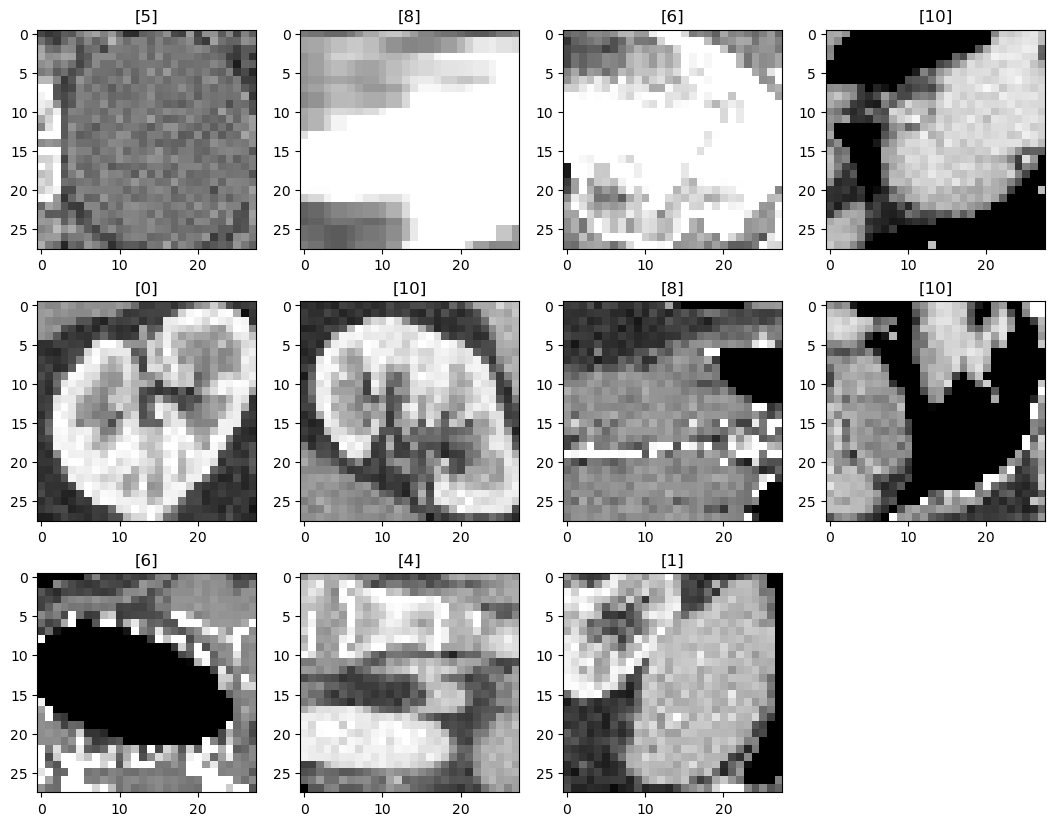

In [8]:
np.unique(train_Y)
unique_obj = []
for i in range(11):
    index = np.where(train_Y == i)[0][0]
    unique_obj.append(index)

unique_imgs = train_X[unique_obj]

fig = plt.figure(figsize = [13,10])
for i in range(11):
    ax = fig.add_subplot(3,4,i+1)
    ax.imshow(unique_imgs[i])
    ax.set_title(train_Y[i])

Text(0.5, 1.0, 'Testing Class Distribution')

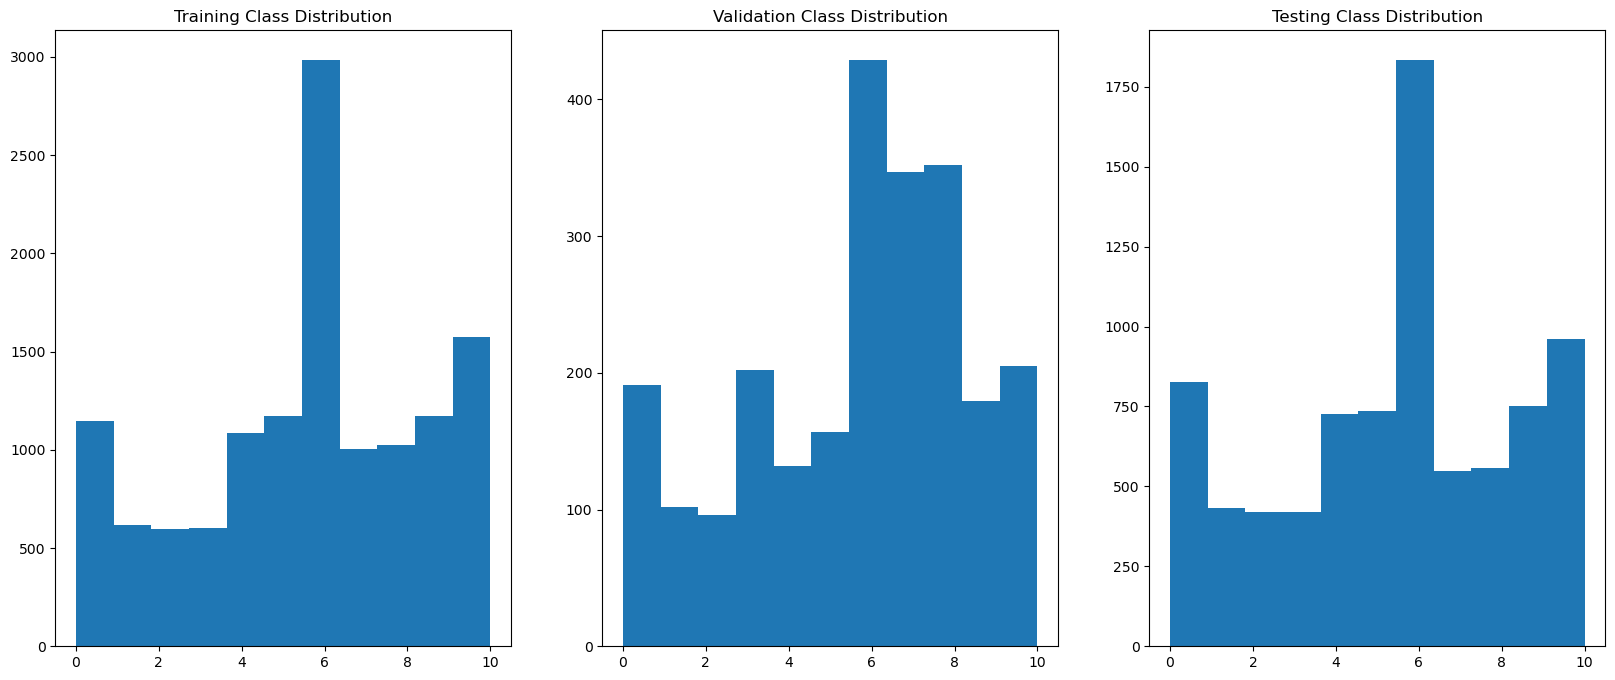

In [9]:
fig = plt.figure(figsize = [20,8])
ax = fig.add_subplot(1,3,1)
ax.hist(train_Y, bins = 11)
ax.set_title("Training Class Distribution")

ax = fig.add_subplot(1,3,2)
ax.hist(val_Y, bins = 11)
ax.set_title("Validation Class Distribution")

ax = fig.add_subplot(1,3,3)
ax.hist(test_Y, bins = 11)
ax.set_title("Testing Class Distribution")


**General Notes:** There is a slight issue with class distribution here, we can see that class 6 dominates the training set with around 2-3 times more samples than the rest. Validation seems to appear more evenly distributed with the bulk of samples at classes 6-8, and testing just resembles similar distributions to the training class. This is mentioned here because you might see better performance on validation accuracy than training accuracy - that's likely because of the training class imbalances. 

# Model Formulation
A MobileNetV2 has been used to assist in identifying early signs of COVID-19 via chest x-rays. This was previously used only on a binary classification task, so I wanted to try this on multi-class classification.

**Notes:**

- Pretrained weights are at the image size 96 x 96. This is the smallest size available, the alternative was to use 224 x 224 which would have been too much pooling for such small images.
- 64 x 64 backbone input. As mentioned, A resize layer will be added to increase the size of the model as 28 x 28 is way too small and is not accepted my MobileNetV2. Some alternatives sizes would've been 32 x 32 or 96 x 96. I found that 32 x 32 was far too small for our pretrained weights, and 96 x 96 consumed too much memory!
- Class weights. Mild class imbalance (3:1 ish) so this should mitigate some at least a little. 
- Frozen everything but the last 29 layers. The last 29 layers of a MobileNet correspond to the last three depthwise separable convolutions, and at this stage, they hold the most important features of the network.
- Classification head: Includes one dense layer (128) and one dropout (0.2) before geting softmaxxed. Didn't want to do too much here but the disconnect between 64 x 64 and 96 x 96 will fuck some stuff up so thats why i have dropout
- Dynamic learning rate just in case training plateaus. From 1e-5 to 1e-7 or something
- 64 batch size and 40 epochs. idk i just like the numbers lol

In [10]:
# using the preloaded imagenet weights for 96 x 96 images 
backbone_96 = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

backbone = keras.applications.MobileNetV2(
                    include_top=False,
                    input_shape=(64,64,3),
                    alpha=1,
                    weights = None,
                    name="back",
                )
backbone.set_weights(backbone_96.get_weights())
backbone.summary()

Model: "back"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [11]:
print("Number of layers in the base model: ", len(backbone.layers))
for layer in backbone.layers[:125]:
    layer.trainable = False

Number of layers in the base model:  154


In [12]:
for layer in backbone.layers:
    print(layer,layer.trainable)

<InputLayer name=input_layer_1, built=True> False
<Conv2D name=Conv1, built=True> False
<BatchNormalization name=bn_Conv1, built=True> False
<ReLU name=Conv1_relu, built=True> False
<DepthwiseConv2D name=expanded_conv_depthwise, built=True> False
<BatchNormalization name=expanded_conv_depthwise_BN, built=True> False
<ReLU name=expanded_conv_depthwise_relu, built=True> False
<Conv2D name=expanded_conv_project, built=True> False
<BatchNormalization name=expanded_conv_project_BN, built=True> False
<Conv2D name=block_1_expand, built=True> False
<BatchNormalization name=block_1_expand_BN, built=True> False
<ReLU name=block_1_expand_relu, built=True> False
<ZeroPadding2D name=block_1_pad, built=True> False
<DepthwiseConv2D name=block_1_depthwise, built=True> False
<BatchNormalization name=block_1_depthwise_BN, built=True> False
<ReLU name=block_1_depthwise_relu, built=True> False
<Conv2D name=block_1_project, built=True> False
<BatchNormalization name=block_1_project_BN, built=True> False
<C

In [13]:
backbone.summary()

Model: "back"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,526,080 (5.82 MB)

 Non-trainable params: 731,904 (2.79 MB)

In [14]:
#mild case of class imbalance, add class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(11),
    y=np.squeeze(train_Y)
)

class_weight_dict = dict(enumerate(class_weights))


In [15]:
inputs = keras.Input((28,28,3))
x = layers.Resizing(height = 64,width = 64,interpolation="bilinear")(inputs) 

#note to self: review different interpolations or padding for resize layer
x = backbone(x)
x = layers.GlobalAveragePooling2D()(x)
x = Dense(128, activation = "relu")(x)
x = layers.Dropout(0.2)(x)
classifier = Dense(11, activation = "softmax", name = 'head')(x)

with_mobile = keras.Model(inputs = inputs, outputs = classifier, name = "MobileNet96")
with_mobile.summary()

Model: "MobileNet96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ back (Functional)               │ (None, 2, 2, 1280)     │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,371 (9.24 MB)

 Trainable params: 1,691,467 (6.45 MB)

 Non-trainable params: 731,904 (2.79 MB)

In [16]:
train_X.shape
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                 patience=5, verbose=0, mode="auto",
                                                 cooldown=0, min_lr=1e-8)

In [ ]:
with_mobile.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              metrics=[keras.metrics.SparseCategoricalAccuracy()], jit_compile=False)
history = with_mobile.fit(train_X, train_Y,
                  batch_size=64,
                  epochs=40,
                  class_weight = class_weight_dict,
                  validation_data=(val_X, val_Y), 
                         callbacks = [lr_scheduler])

Epoch 1/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - loss: 2.2654 - sparse_categorical_accuracy: 0.3028 - val_loss: 2.2681 - val_sparse_categorical_accuracy: 0.2985 - learning_rate: 1.0000e-05
Epoch 2/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 2.0129 - sparse_categorical_accuracy: 0.5877 - val_loss: 2.1073 - val_sparse_categorical_accuracy: 0.5393 - learning_rate: 1.0000e-05
Epoch 3/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 1.9083 - sparse_categorical_accuracy: 0.6793 - val_loss: 2.0150 - val_sparse_categorical_accuracy: 0.5978 - learning_rate: 1.0000e-05
Epoch 4/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 1.8545 - sparse_categorical_accuracy: 0.7253 - val_loss: 1.9583 - val_sparse_categorical_accuracy: 0.6467 - learning_rate: 1.0000e-05
Epoch 5/40
203/203 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 1.8136 - sparse_categorical_accuracy: 0.7647 - val_loss: 1.9039 - val_sparse_categorical_accuracy: 0.6898 - learning_rate: 1.0000e-05
Epoch 6/40
203/203 ━

# Evaluation
The training process and confusion matrices will be plotted her

In [ ]:
def plot_accuracy(history):
    fig = plt.figure(figsize=[20, 6])
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(history.history['sparse_categorical_accuracy'], label="Training Accuracy")
    ax.plot(history.history['val_sparse_categorical_accuracy'], label="Validation Accuracy")
    ax.legend()
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(history.history['loss'], label="Training Loss")
    ax.plot(history.history['val_loss'], label="Validation Loss")
    ax.legend();

In [ ]:
plot_accuracy(history)

In [ ]:
import tensorflow as tf

In [ ]:
def eval_model(model, train, train_y, test, test_y):
    fig = plt.figure(figsize=[20, 8])    

    ax = fig.add_subplot(1, 2, 1)    
    # predict on the training set
    pred_cls = model.predict(train, verbose=False);
    indexes = tf.argmax(pred_cls, axis=1)

    # plot the confusion matrix, I'm using tensorflow and seaborn here, but you could use
    # sklearn as well
    confusion_mtx = confusion_matrix(train_y, indexes)
    sns.heatmap(confusion_mtx, xticklabels=range(11), yticklabels=range(11), 
            annot=True, fmt='g', ax=ax)
    # set the title to the F1 scope
    ax.set_title('Training, F1 Score: %f' % f1_score(train_y, indexes, average='weighted'))

    # repeat visualisation for the test set
    ax = fig.add_subplot(1, 2, 2)  
    pred_cls = model.predict(test, verbose=False);
    indexes = tf.argmax(pred_cls, axis=1)

    confusion_mtx = confusion_matrix(test_y, indexes)
    sns.heatmap(confusion_mtx, xticklabels=range(11), yticklabels=range(11), 
            annot=True, fmt='g', ax=ax)
    ax.set_title('Testing, F1 Score: %f' % f1_score(test_y, indexes, average='weighted'))

In [ ]:
eval_model(with_mobile,train_X,train_Y,test_X,test_Y)

In [ ]:
y_true = test_Y
y_pred = with_mobile.predict(test_X)
y_pred = np.argmax(y_pred, axis = 1)
#target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred))